In [1]:
import sys
import os
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
from starcat import BuildConsensusReference, starCAT

/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/minicon

In [2]:

work_dir = "./5.3.organ/"

# 2. 如果文件夹不存在，自动创建它 (推荐加上这行，防止报错)
if not os.path.exists(work_dir):
    os.makedirs(work_dir)

# 3. 切换当前工作目录
os.chdir(work_dir)

# 4. 打印确认一下现在的路径
print(f"当前工作目录已切换至: {os.getcwd()}")


当前工作目录已切换至: /sibcb1/bioinformatics/yangyue/project/immunotherapy/7.2.cNMF_CD8T/5.disease/5.3.organ


In [3]:
import numpy as np
import scanpy as sc

# 1. 读取数据
adata = sc.read_h5ad(
    "/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.2.cNMF_CD8T/5.3_startCAT-organoids/GSE248788/GSE248789_scRNA_clean_anno.h5ad"
)

# 2. 只保留 T 细胞
t_adata = adata[adata.obs['celltype'] == 'CD8T'].copy()

# 5. 只提取 CD8T —— 后续分析唯一对象
query_adata = t_adata[t_adata.obs['celltype'] == 'CD8T'].copy()
query_adata

AnnData object with n_obs × n_vars = 8736 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'T_clonotype_id', 'T_cdr3s_aa', 'T_frequency', 'B_clonotype_id', 'B_cdr3s_aa', 'B_frequency', 'Condition', 'RNA_snn_res.0.6', 'seurat_clusters', 'cell_type', 'celltype', 'barcode'
    obsm: 'X_pca', 'X_umap'

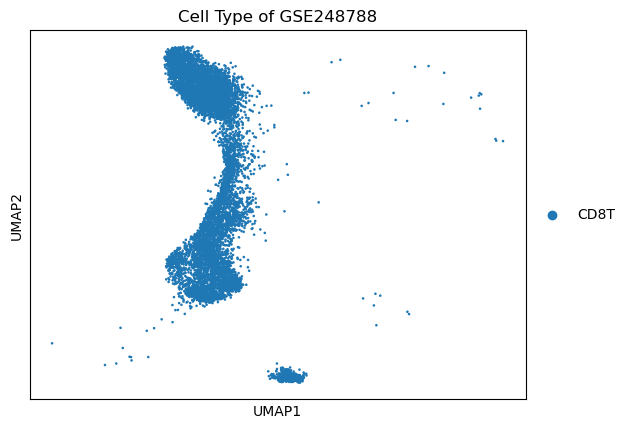

In [4]:
sc.pl.umap(query_adata, color='celltype', title='Cell Type of GSE248788')

In [5]:
query_adata.obs['Condition'].value_counts()

ATMR      5671
Stable    3065
Name: Condition, dtype: int64

In [6]:
query_adata.obs['hash.ID']

TK1_AAACCTGCAATAACGA-1    HTO252
TK1_AAACCTGCAGGGTATG-1    HTO252
TK1_AAACCTGGTAAGTGTA-1    HTO252
TK1_AAACCTGGTAGCAAAT-1    HTO253
TK1_AAACCTGGTATGCTTG-1    HTO251
                           ...  
TK3_TTTGTCAAGTAGCCGA-1    HTO262
TK3_TTTGTCACAAAGGAAG-1    HTO263
TK3_TTTGTCAGTATAATGG-1    HTO259
TK3_TTTGTCATCCAAACTG-1    HTO259
TK3_TTTGTCATCTGTGCAA-1    HTO262
Name: hash.ID, Length: 8736, dtype: category
Categories (12, object): ['HTO251', 'HTO252', 'HTO253', 'HTO254', ..., 'HTO259', 'HTO260', 'HTO262', 'HTO263']

In [7]:
# 查看 group 列包含的所有类别
print(query_adata.obs['Condition'].unique().tolist())
# 1. 定义您想挑出的组名列表
target_groups = ['ATMR', 'Stable']  # 请根据第一步的输出结果修改这里！

# 2. 提取子集并生成一个新的 AnnData 对象
# 注意结尾加上 .copy()，避免修改子集时影响原数据
control_adata = query_adata[query_adata.obs['Condition'].isin(target_groups)].copy()

# 3. 查看提取后的结果
print(f"提取完成！剩余细胞数: {control_adata.n_obs}")
print("包含的组别:", control_adata.obs['Condition'].unique().tolist())
# ==========================================
# 1. 查看对照组中【总共】有几个不同的病人
# ==========================================
num_control_patients = control_adata.obs['hash.ID'].nunique()
print(f"✅ 对照组中总共有 {num_control_patients} 个不重复的病人/样本。")

# ==========================================
# 2. 查看具体的【病人 ID 列表】
# ==========================================
control_patient_ids = control_adata.obs['hash.ID'].unique().tolist()
print(f"🔍 对照组的病人 ID 列表: {control_patient_ids}")

# ==========================================
# 3. 进阶：查看【每个具体分组】下分别有几个病人
# ==========================================
# 比如看看 'Healthy' 里有几个，'Control' 里有几个
patients_per_group = control_adata.obs.groupby('Condition')['hash.ID'].nunique()
print("\n📊 各个对照分组的病人数量统计：")
print(patients_per_group)

['ATMR', 'Stable']
提取完成！剩余细胞数: 8736
包含的组别: ['ATMR', 'Stable']
✅ 对照组中总共有 12 个不重复的病人/样本。
🔍 对照组的病人 ID 列表: ['HTO252', 'HTO253', 'HTO251', 'HTO254', 'HTO256', 'HTO258', 'HTO257', 'HTO255', 'HTO259', 'HTO260', 'HTO262', 'HTO263']

📊 各个对照分组的病人数量统计：
Condition
ATMR      8
Stable    4
Name: hash.ID, dtype: int64


In [8]:

custom_tcat = starCAT(reference='/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.2.cNMF_CD8T/Example_refbuilder_95_v2/starcat_refstarcat_consensus_spectra_normalized.filtered.txt')

usage, _ = custom_tcat.fit_transform(query_adata)


Using user specified reference spectra file /sibcb1/bioinformatics/yangyue/project/immunotherapy/7.2.cNMF_CD8T/Example_refbuilder_95_v2/starcat_refstarcat_consensus_spectra_normalized.filtered.txt
No scores provided
5329 out of 5329 genes in the reference overlap with the query


In [9]:
usage.to_csv("/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.2.cNMF_CD8T/5.disease/5.3.organ/5.3.GSE248788_CD8T_cGEP_usage_cell_level.csv")

In [10]:
# 加上70个cGEP对应的注释
gep_anno = pd.read_csv("../../3.cGEP_topgene/3.3.CD8T_cGEP_Anno_Complete_With_Genes.csv")

# 去掉 Class 为 Artifact 或 Doublet Lineage 的行
gep_anno_filt = gep_anno[~gep_anno["Category"].isin(["Artifact", "Doublet"])]
# 1. 找出 Artifact / Doublet  对应的 cGEP 名称
remove_geps = (
    gep_anno.loc[
        gep_anno["Category"].isin(["Artifact", "Doublet"]),
        "cGEP_Cluster"]
    .unique()
    .tolist()
)

print("需要去掉的 cGEP：", remove_geps)

# 2. 从 usage 表格中去掉这些 cGEP 列
usage = usage.drop(columns=remove_geps, errors="ignore")

usage

需要去掉的 cGEP： ['cGEP9', 'cGEP13', 'cGEP14', 'cGEP18', 'cGEP24', 'cGEP38', 'cGEP39', 'cGEP41', 'cGEP43', 'cGEP47', 'cGEP48', 'cGEP51', 'cGEP53', 'cGEP60', 'cGEP61', 'cGEP63', 'cGEP64', 'cGEP65', 'cGEP70']


,cGEP1,cGEP2,cGEP3,cGEP4,cGEP5,cGEP6,cGEP7,cGEP8,cGEP10,cGEP11,...,cGEP55,cGEP56,cGEP57,cGEP58,cGEP59,cGEP62,cGEP66,cGEP67,cGEP68,cGEP69
TK1_AAACCTGCAATAACGA-1,1.812824e-02,0.003285,0.017564,0.008957,0.018869,0.002528,0.033644,0.018019,0.031100,0.007847,...,0.013930,0.003429,0.016524,0.086058,0.004902,0.029451,0.010846,4.146290e-03,0.051874,1.054619e-03
TK1_AAACCTGCAGGGTATG-1,8.616319e-02,0.001303,0.014029,0.024669,0.022826,0.000587,0.004448,0.003290,0.003651,0.005248,...,0.016336,0.001802,0.003071,0.088052,0.000577,0.056030,0.000499,2.659020e-03,0.008015,1.867174e-02
TK1_AAACCTGGTAAGTGTA-1,3.997584e-05,0.002028,0.000549,0.000204,0.002650,0.001599,0.001739,0.023058,0.001839,0.005056,...,0.002503,0.000870,0.004463,0.002553,0.003760,0.000824,0.001750,2.105356e-06,0.307237,8.357853e-06
TK1_AAACCTGGTAGCAAAT-1,2.200460e-03,0.024423,0.004320,0.001083,0.013086,0.013929,0.000769,0.014193,0.006600,0.000291,...,0.027628,0.012686,0.015075,0.011802,0.007969,0.010612,0.005245,4.629198e-04,0.177606,1.983932e-03
TK1_AAACCTGGTATGCTTG-1,1.981022e-03,0.002267,0.011332,0.002268,0.008292,0.000826,0.002559,0.003587,0.021725,0.009343,...,0.007304,0.001528,0.006327,0.001883,0.000681,0.002260,0.052611,2.688165e-03,0.185496,2.157188e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TK3_TTTGTCAAGTAGCCGA-1,5.981896e-03,0.002913,0.004631,0.013648,0.000570,0.003605,0.003000,0.023985,0.016493,0.048413,...,0.031347,0.007760,0.005196,0.088820,0.006766,0.049033,0.027332,5.138582e-06,0.081010,2.094586e-04
TK3_TTTGTCACAAAGGAAG-1,3.054393e-02,0.004745,0.007040,0.021228,0.004803,0.002337,0.014197,0.006170,0.006619,0.014194,...,0.020983,0.004109,0.010537,0.128393,0.001313,0.056357,0.004951,3.500939e-03,0.006989,1.381301e-02
TK3_TTTGTCAGTATAATGG-1,4.548119e-02,0.001646,0.018698,0.083953,0.004233,0.001008,0.018577,0.001852,0.010002,0.236969,...,0.000296,0.002400,0.005957,0.025952,0.000239,0.012909,0.010696,2.820520e-03,0.000148,8.841187e-03
TK3_TTTGTCATCCAAACTG-1,8.292093e-08,0.003889,0.000216,0.000001,0.023755,0.007218,0.002123,0.001385,0.000210,0.043608,...,0.000231,0.000103,0.016045,0.000007,0.043199,0.003855,0.004047,1.739634e-07,0.134894,5.586650e-07


In [11]:
# 1. 修正字典构建逻辑
# 去掉代码中的 "cGEP" 前缀，直接读取
anno_dict = {
    row['cGEP_Cluster']: f"{row['cGEP_Cluster']}_{row['cGEP_Anno_Name']}" 
    for index, row in gep_anno_filt.iterrows()
}

# 2. 再次检查映射字典
# 正确的样子应该是: [('cGEP1', 'cGEP1_Translation'), ...]
print("修正后的映射字典 (前3个):")
print(list(anno_dict.items())[:3])

# 3. 执行重命名
usage.rename(columns=anno_dict, inplace=True)

# 4. 验证结果
print("新的列名:")
print(usage.columns[:5])

修正后的映射字典 (前3个):
[('cGEP1', 'cGEP1_Ribo_Bio'), ('cGEP2', 'cGEP2_Type1_IFN'), ('cGEP3', 'cGEP3_Metab_OXPHOS')]
新的列名:
Index(['cGEP1_Ribo_Bio', 'cGEP2_Type1_IFN', 'cGEP3_Metab_OXPHOS',
       'cGEP4_Transl_Elong', 'cGEP5_Metab_Resp'],
      dtype='object')


In [12]:
# ===========================
# 步骤 1: 准备数据到 obs 中
# ===========================
print("正在将 Usage 数据同步到 adata.obs...")

# 获取 usage 表格中所有的列名（即所有的 GEP 名字）
all_gep_names = usage.columns.tolist()

# 将这些数据赋值给 query_adata.obs
# 我们加一个统一的前缀 "Usage: "，这样在图的标题里看起来更清晰
plot_features_list = []
for col in all_gep_names:
    # 新名字例如："Usage: cGEP1_Translation"
    new_obs_name = f"Usage: {col}"
    query_adata.obs[new_obs_name] = usage[col].values
    plot_features_list.append(new_obs_name)

n_geps = len(plot_features_list)
print(f"准备就绪，共计 {n_geps} 个 GEP 将被绘制。")

正在将 Usage 数据同步到 adata.obs...
准备就绪，共计 51 个 GEP 将被绘制。


正在将 Usage 数据同步到 adata.obs...
准备就绪，共计 51 个 GEP 将被绘制。
开始绘制 UMAP，这可能需要一点时间...


/var/tmp/ipykernel_222514/3895156732.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.show()



>>> 绘图完成！ <<<


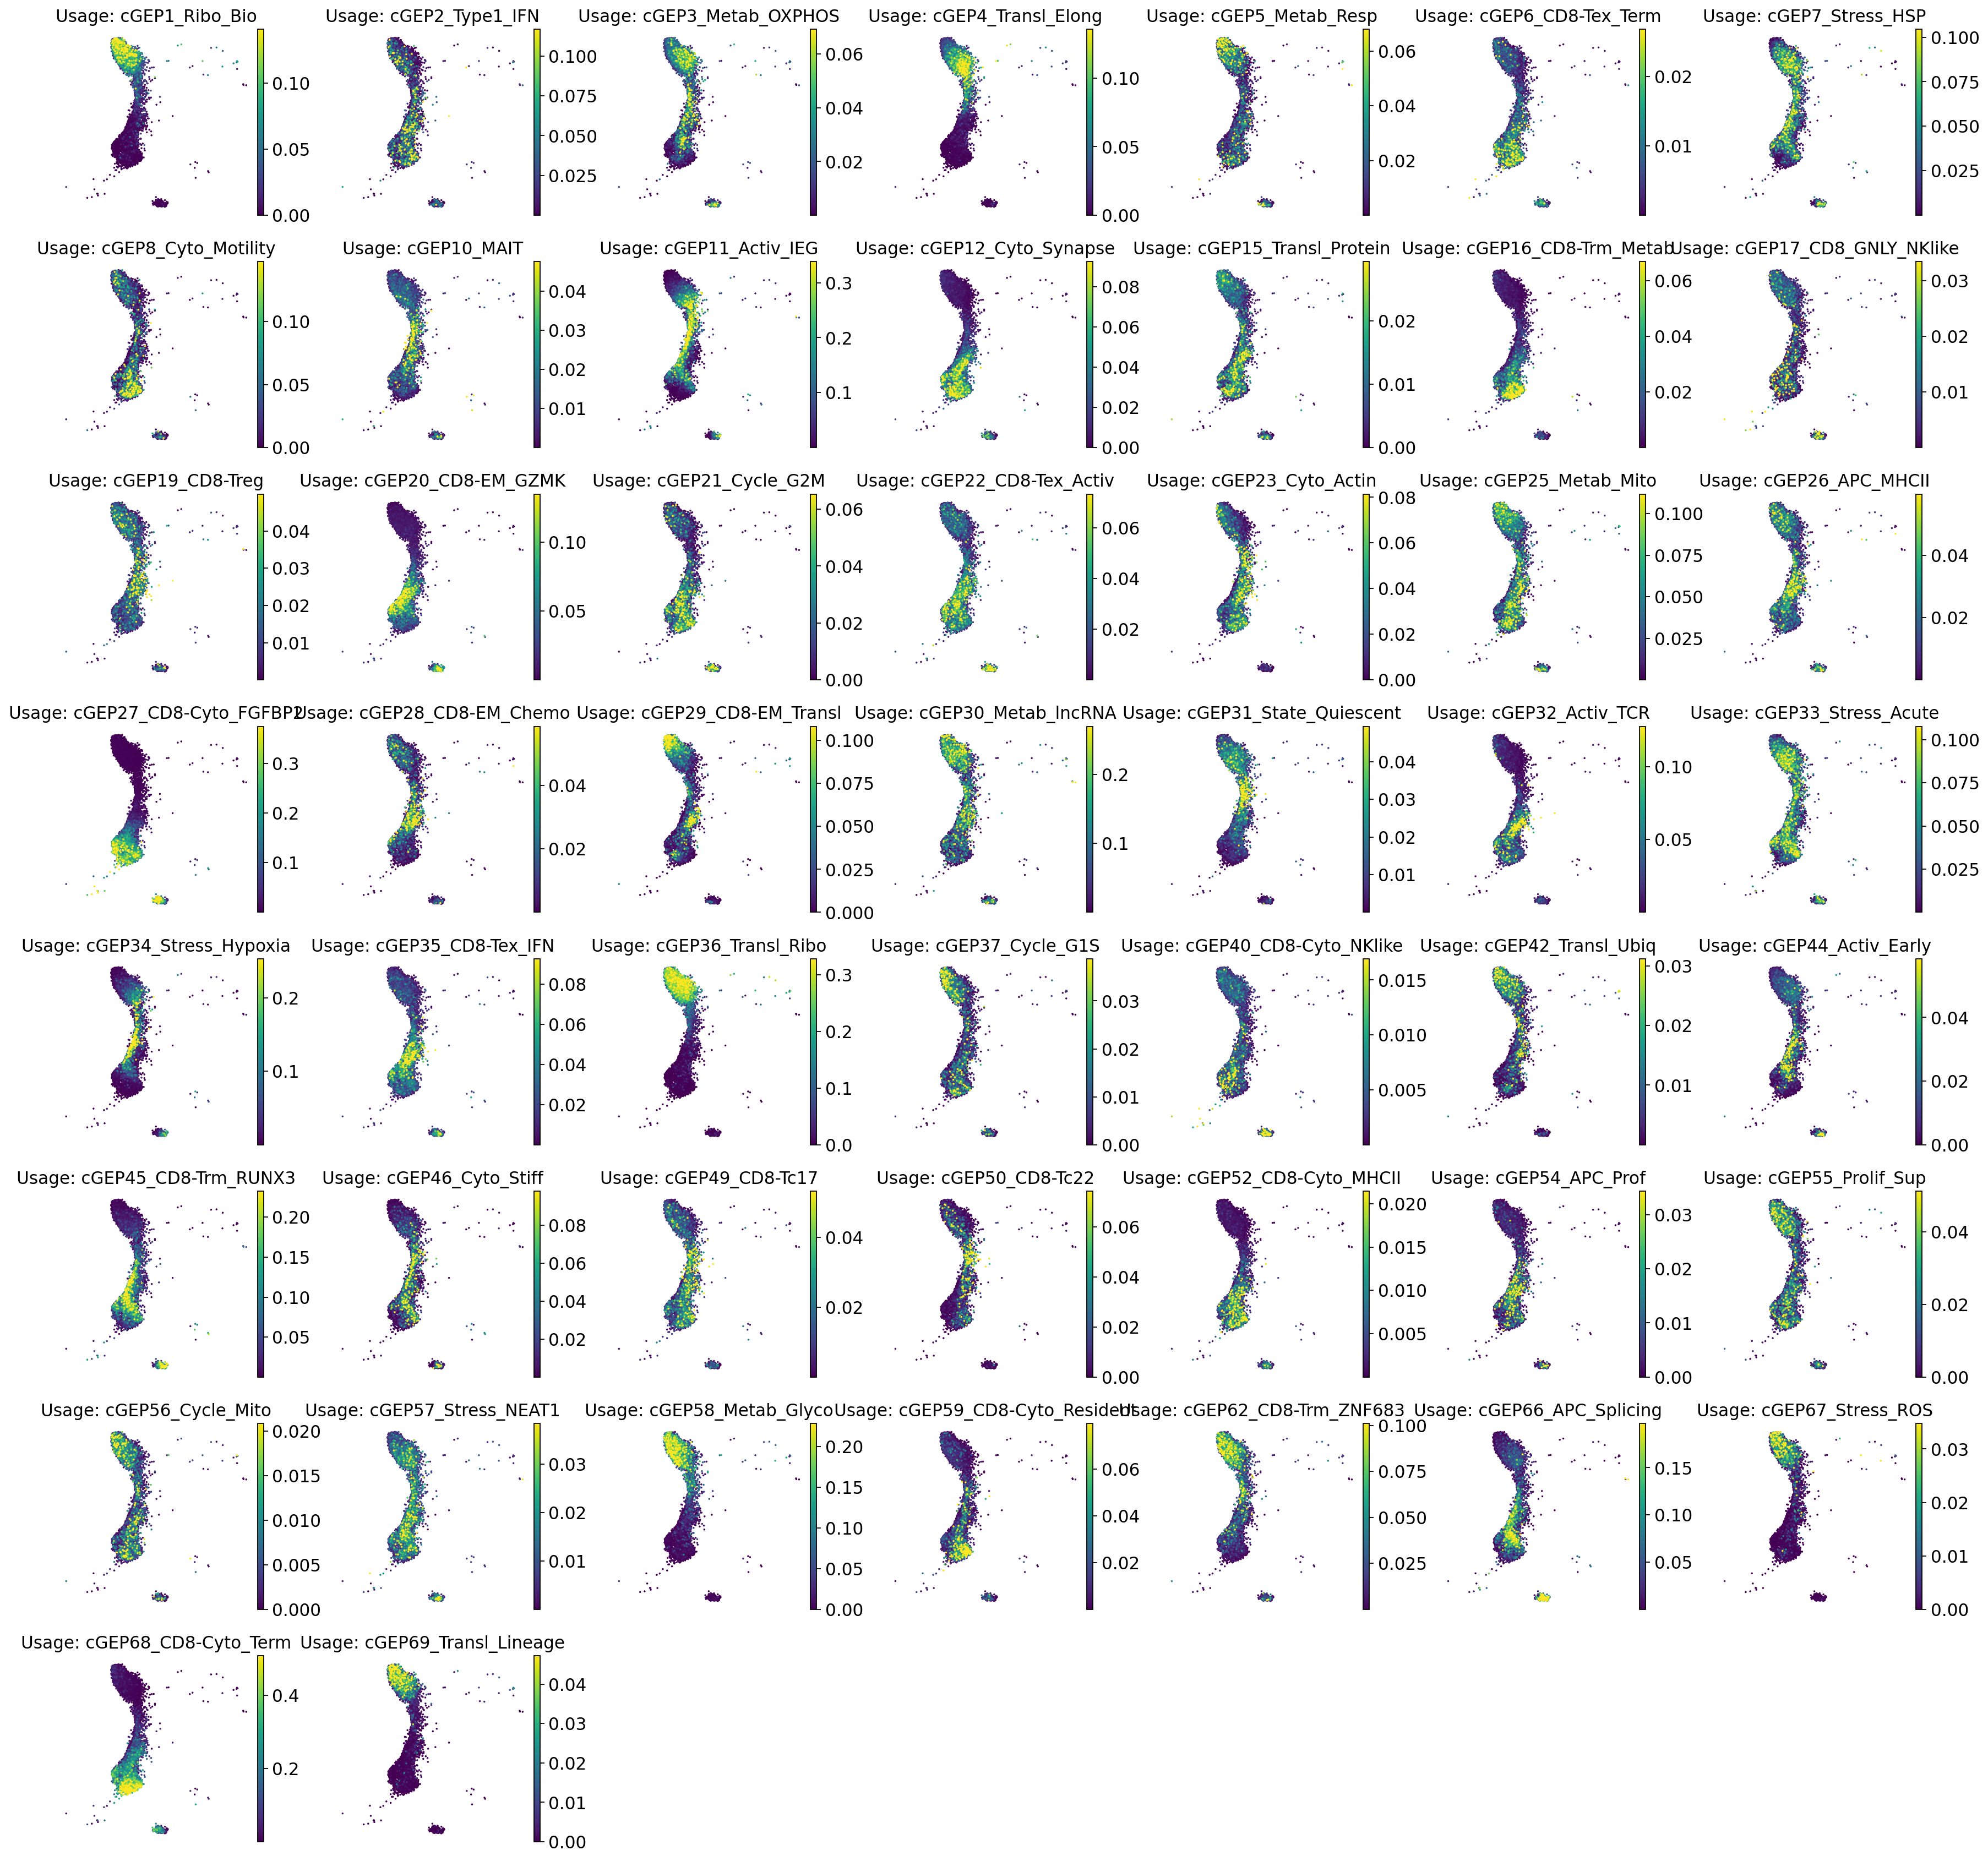

In [13]:
# ===========================
# 步骤 1: 准备数据到 obs 中
# ===========================
print("正在将 Usage 数据同步到 adata.obs...")

# 获取 usage 表格中所有的列名（即所有的 GEP 名字）
all_gep_names = usage.columns.tolist()

# 将这些数据赋值给 query_adata.obs
# 我们加一个统一的前缀 "Usage: "，这样在图的标题里看起来更清晰
plot_features_list = []
for col in all_gep_names:
    # 新名字例如："Usage: cGEP1_Translation"
    new_obs_name = f"Usage: {col}"
    query_adata.obs[new_obs_name] = usage[col].values
    plot_features_list.append(new_obs_name)

n_geps = len(plot_features_list)
print(f"准备就绪，共计 {n_geps} 个 GEP 将被绘制。")


# ===========================
# 步骤 2: 批量绘图并保存
# ===========================
print("开始绘制 UMAP，这可能需要一点时间...")

# 设置绘图参数
sc.set_figure_params(dpi_save=300, figsize=(3, 3)) # 设置每一张小图的尺寸和保存分辨率

plot = sc.pl.umap(
    query_adata,
    color=plot_features_list, # 传入包含所有名字的列表
    vmax='p99',        # 关键：切除前1%的极端值，否则图可能一片黑
    cmap='viridis',    # 配色方案：viridis(黄紫), plasma(黄蓝), Reds(红)
    ncols=7,           # 每行显示 7 张图 (根据总数调整，70个正好画10行)
    s=10,              # 点的大小
    frameon=False,     # 去掉外边框，更美观
    show=False,        # 关键：设置为 False，不直接在屏幕显示
    return_fig=True    # 返回图像对象以便保存
)
plot.show()
# 定义保存路径
#output_filename = "5.All_GEP_Usage_Visualization.png"

# 保存图片
# bbox_inches='tight' 可以去除多余白边
#plot.savefig(output_filename, bbox_inches='tight')

print(f"\n>>> 绘图完成！ <<<")


图片已保存为: 5.3.GSE248788_CD8T_Usage_Heatmap_Right_Legend2.png


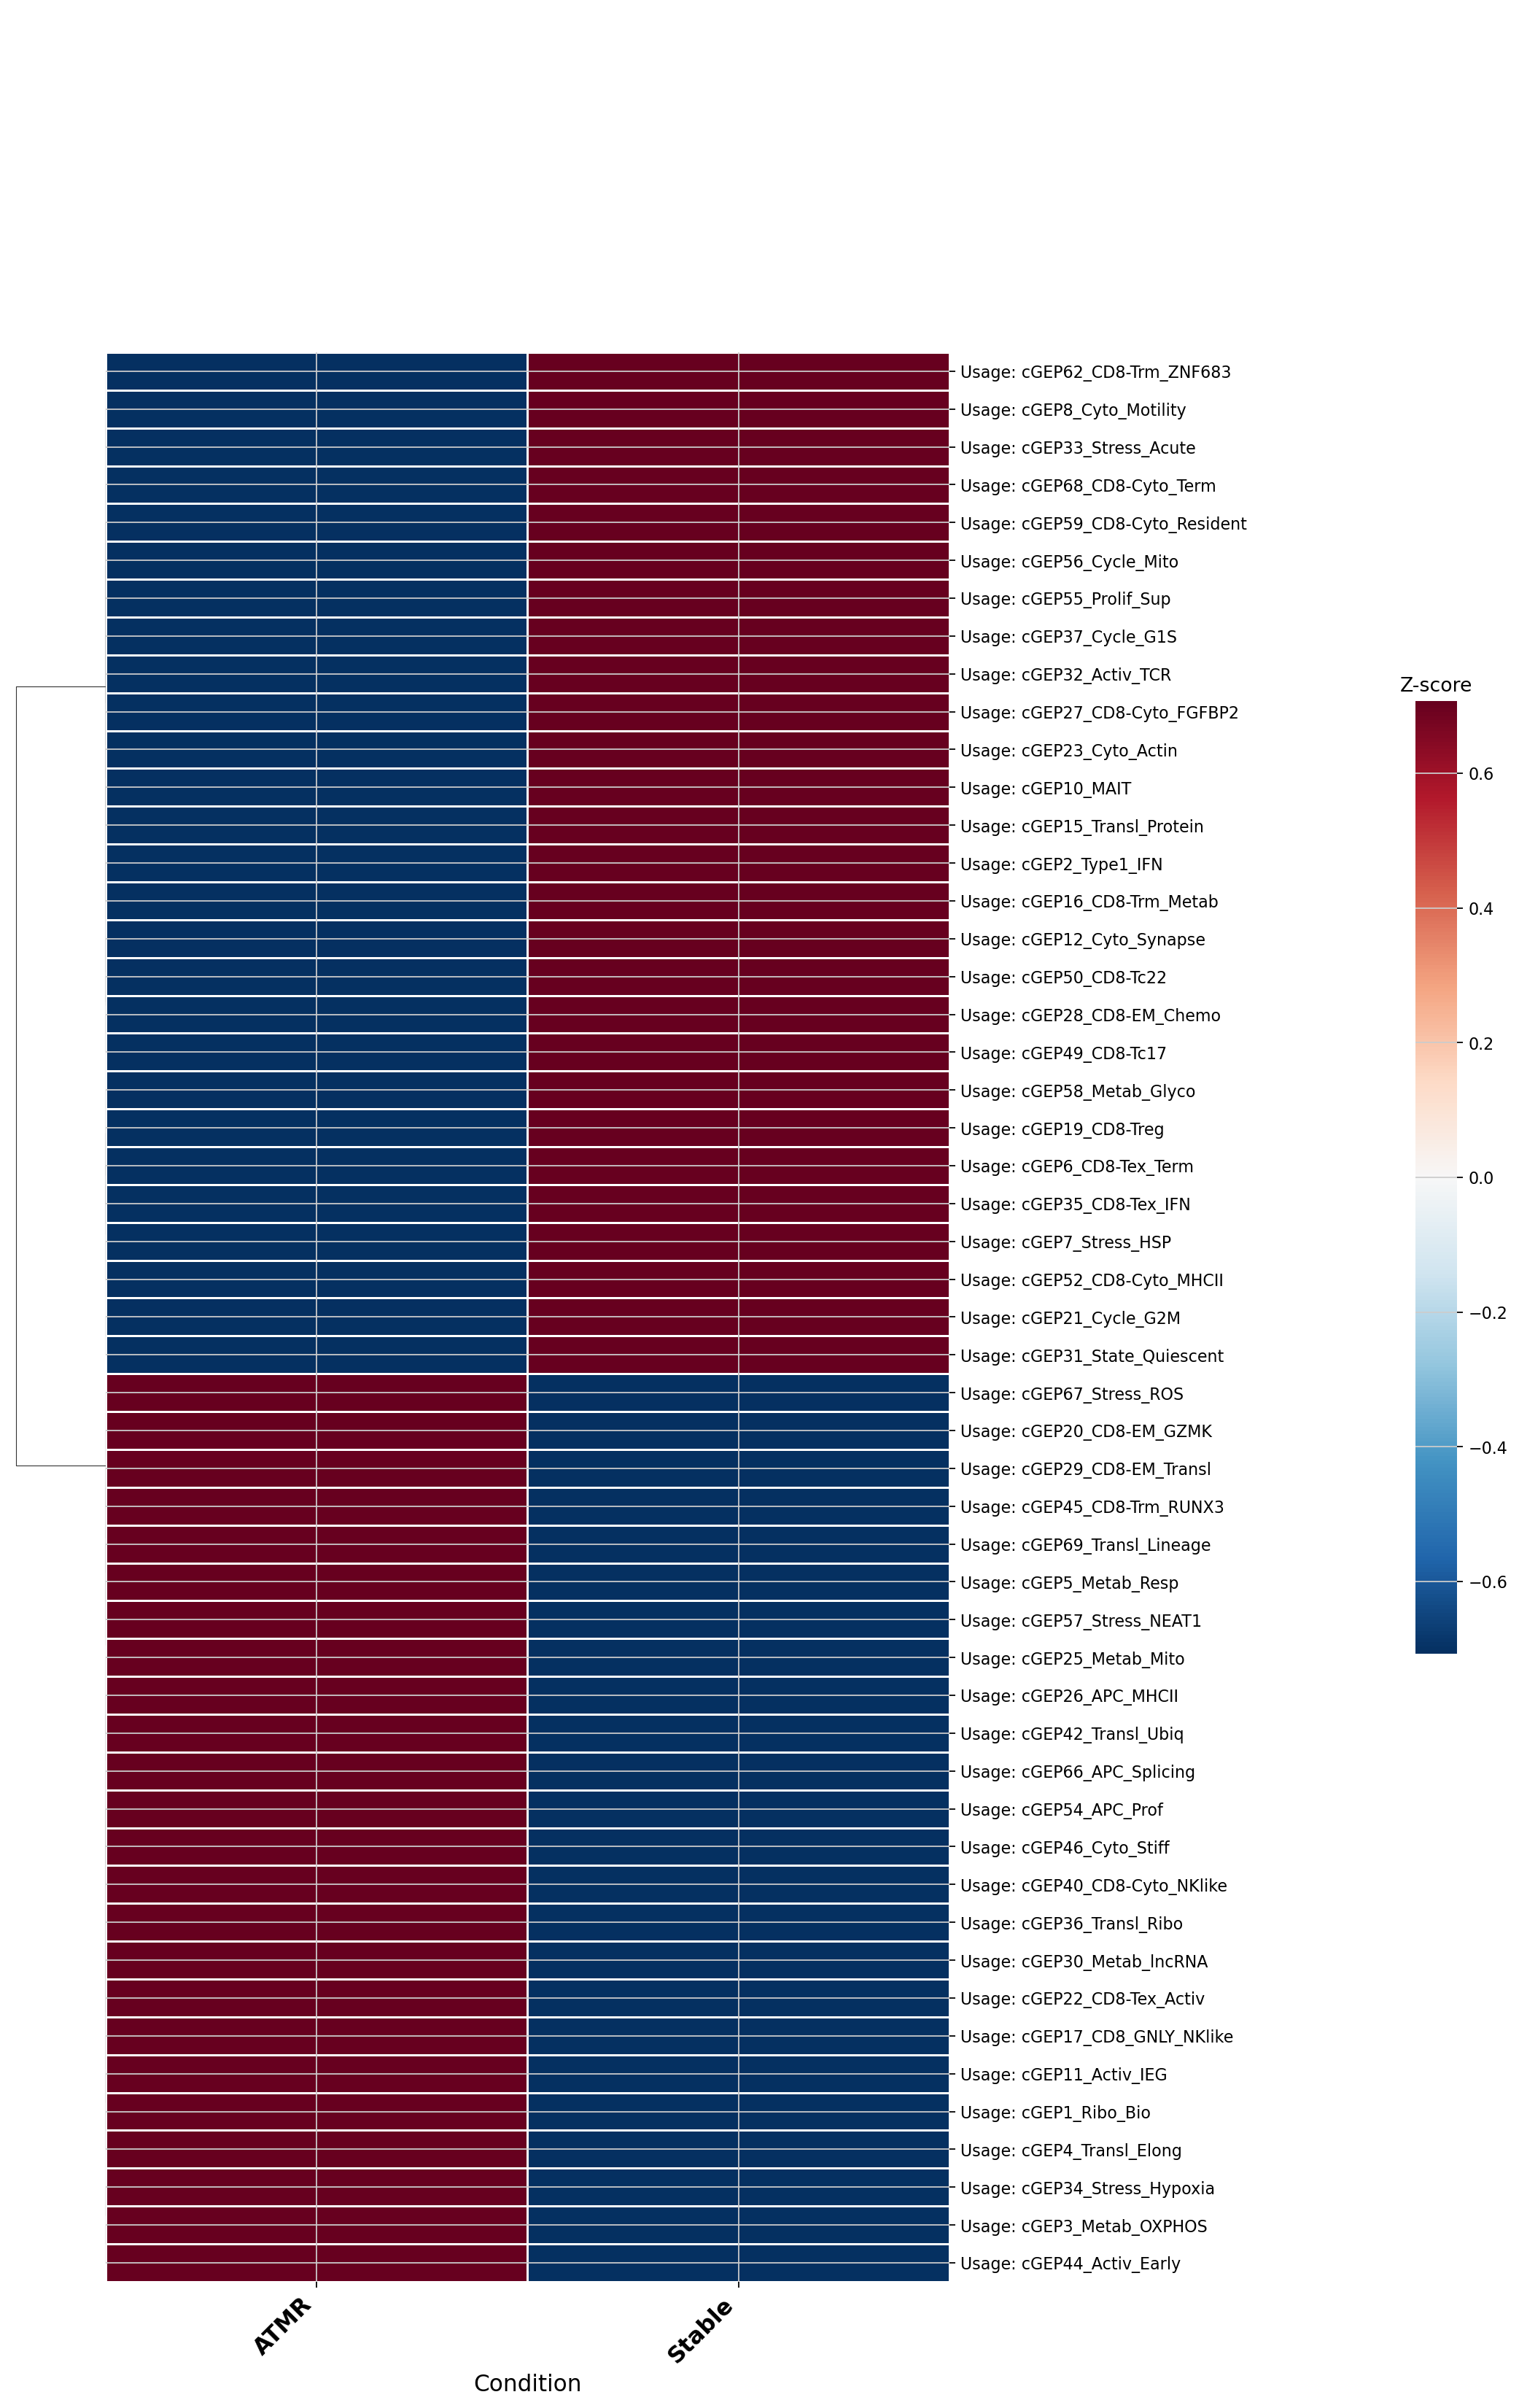

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 筛选数据 (保持不变)
usage_features = [col for col in query_adata.obs.columns if col.startswith('Usage:')]
df = query_adata.obs[usage_features + ['Condition']]
mean_usage = df.groupby('Condition').mean()

# 2. 绘制热图
g = sns.clustermap(
    mean_usage.T,
    z_score=0,
    cmap='RdBu_r',
    center=0,
    col_cluster=False,
    # 画布大小
    figsize=(12, len(usage_features) * 0.4),
    cbar_pos=(1.02, 0.3, 0.03, 0.4), 
    dendrogram_ratio=(0.1, 0.15),
    linewidths=0.5,
    linecolor='white',
    xticklabels=True,
    yticklabels=True
)

# 3. 调整字体和样式
plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=14, fontweight='bold', rotation=45, ha='right')
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=10)

# 4. 优化右侧图例的标签
g.ax_cbar.set_title('Z-score', fontsize=12) # 给图例加标题
g.ax_cbar.tick_params(labelsize=10)         # 调整图例刻度字号

# 5. 保存 (bbox_inches='tight' 至关重要，否则右边的图例会被切掉)
output_filename = "5.3.GSE248788_CD8T_Usage_Heatmap_Right_Legend2.png"
g.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"图片已保存为: {output_filename}")

plt.show()

>>> 正在对比: Antibody-Mediated_Rejection vs Stable_Allograft...
分析完成。前 5 个显著差异 GEP:
                        GEP_Name    log2FC           padj
0      Usage: cGEP3_Metab_OXPHOS  1.316424  1.185590e-224
1     Usage: cGEP66_APC_Splicing  1.750429  2.428544e-159
2      Usage: cGEP44_Activ_Early  1.289227  1.730087e-150
3   Usage: cGEP34_Stress_Hypoxia  2.121086  1.377243e-140
4  Usage: cGEP40_CD8-Cyto_NKlike  0.691765   3.007436e-76

分析完成。以下是将在火山图上标注的极显著 cGEP：

--- 在  中最显著上调的 Top 5 cGEP (对应图右侧红点) ---
                  GEP_Name   log2FC          padj   log_pval
 Usage: cGEP3_Metab_OXPHOS 1.316424 1.185590e-224 223.926065
Usage: cGEP66_APC_Splicing 1.750429 2.428544e-159 158.614654
 Usage: cGEP44_Activ_Early 1.289227 1.730087e-150 149.761932

--- 在  中最显著下调的 Top 5 cGEP (对应图左侧蓝点) ---
                  GEP_Name    log2FC          padj   log_pval
  Usage: cGEP23_Cyto_Actin -0.566497 1.315014e-134 133.881070
    Usage: cGEP2_Type1_IFN -1.084521 1.689043e-124 123.772359
Usage: cGEP33_Stress_Acute -0.7

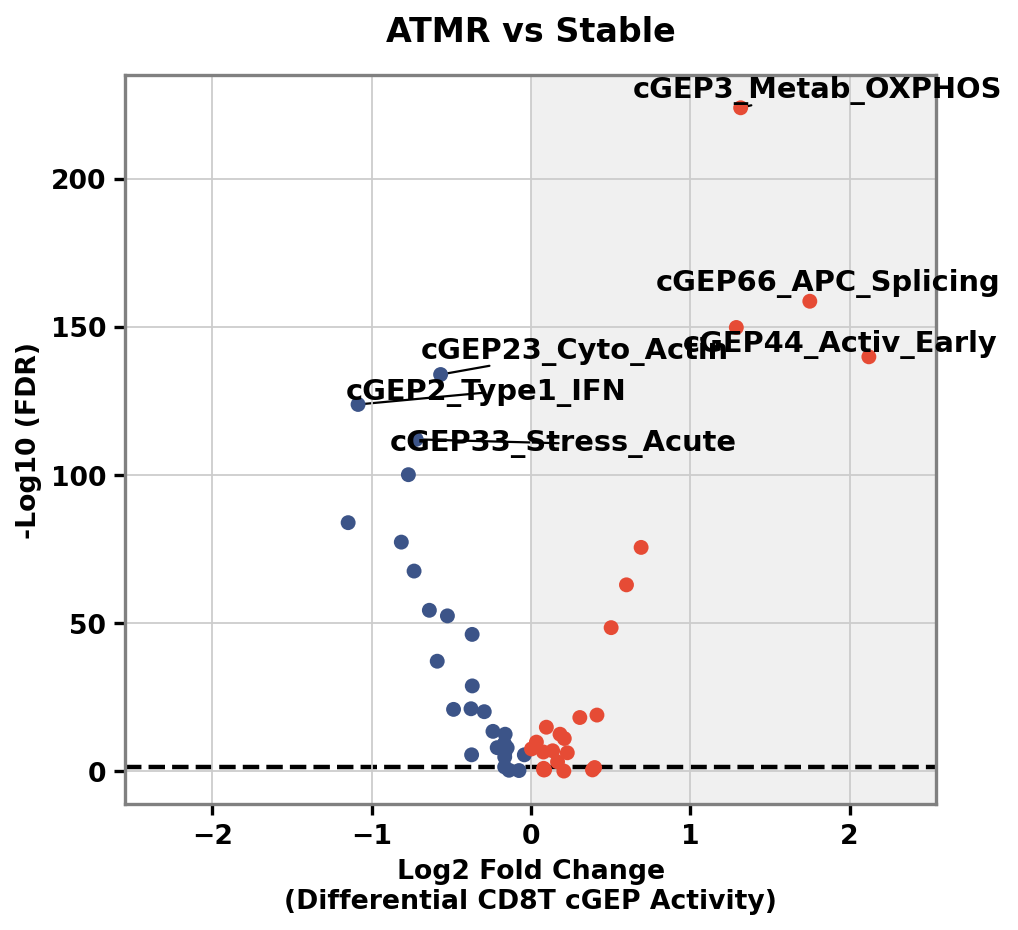

In [19]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

# ===========================
# 第一步：准备数据与差异分析
# ===========================

# 1. 提取所有 Usage 列
usage_cols = [c for c in query_adata.obs.columns if c.startswith('Usage:')]
gep_data = query_adata.obs[usage_cols]

# 2. 创建临时 AnnData 对象
gep_adata = sc.AnnData(X=gep_data.values, obs=query_adata.obs)
gep_adata.var_names = usage_cols

# 3. 运行差异分析 (Wilcoxon 秩和检验)

target_group = 'Antibody-Mediated_Rejection'
ref_group = 'Stable_Allograft'

print(f">>> 正在对比: {target_group} vs {ref_group}...")

sc.tl.rank_genes_groups(
    gep_adata, 
    groupby='group2_condition', 
    groups=[target_group], 
    reference=ref_group, 
    method='wilcoxon'
)

# 4. 提取结果表
result = sc.get.rank_genes_groups_df(gep_adata, group=target_group)
df_volcano = result[['names', 'logfoldchanges', 'pvals_adj']].copy()
df_volcano.columns = ['GEP_Name', 'log2FC', 'padj']

# 去除无效值
df_volcano = df_volcano.replace([np.inf, -np.inf], np.nan).dropna()
print("分析完成。前 5 个显著差异 GEP:")
print(df_volcano.head())

# ===========================
# 第二步：绘制高分文献风格火山图
# ===========================

# 1. 设置显著性阈值
pval_th = 0.05
# 参考图只画了横线，因此不再设置强硬的竖线 logFC 阈值，靠左右分布区分

# 2. 定义颜色 (仿照参考图，按正负着色：右侧红色，左侧蓝色)
df_volcano['color'] = np.where(df_volcano['log2FC'] > 0, '#E64B35', '#3C5488') 
df_volcano['alpha'] = 1.0

# 计算 -log10 P值
df_volcano['log_pval'] = -np.log10(df_volcano['padj'] + 1e-300) 

# 3. 开始绘图
fig, ax = plt.subplots(figsize=(6.5, 6)) # 采用接近正方形的比例

# 【关键特征】添加右侧灰色阴影背景
# 获取X轴最大值以确定阴影右边界
x_max = abs(df_volcano['log2FC']).max() * 1.2 
ax.axvspan(0, x_max, facecolor='#f0f0f0', zorder=0)

# 绘制散点
ax.scatter(
    df_volcano['log2FC'], 
    df_volcano['log_pval'], 
    c=df_volcano['color'], 
    s=45, 
    alpha=df_volcano['alpha'], 
    edgecolors='none', 
    zorder=2
)

# 【关键特征】只添加水平黑色粗虚线作为 Q-value/P-value 阈值
ax.axhline(y=-np.log10(pval_th), color='black', linestyle='--', linewidth=2, zorder=1)

# 4. 标注显著的点
texts = []
# 选取 P 值最显著的 top 15 个点进行标注（由于没有中间的垂直线，符合条件的可能较多）

# 提取 P 值最显著的 Top 5 上调和下调 cGEP（用于打印和图表标注）
top_up = df_volcano[(df_volcano['log2FC'] > 0) & (df_volcano['padj'] < pval_th)].sort_values('padj').head(3)
top_dn = df_volcano[(df_volcano['log2FC'] < 0) & (df_volcano['padj'] < pval_th)].sort_values('padj').head(3)
top_genes = pd.concat([top_up, top_dn])

print("\n分析完成。以下是将在火山图上标注的极显著 cGEP：")
print("\n--- 在  中最显著上调的 Top 5 cGEP (对应图右侧红点) ---")
print(top_up[['GEP_Name', 'log2FC', 'padj', 'log_pval']].to_string(index=False))

print("\n--- 在  中最显著下调的 Top 5 cGEP (对应图左侧蓝点) ---")
print(top_dn[['GEP_Name', 'log2FC', 'padj', 'log_pval']].to_string(index=False))

for _, row in top_genes.iterrows():
    simple_name = row['GEP_Name'].replace('Usage: ', '')
    # 【全局加粗】添加字体加粗参数 fontweight='bold'
    texts.append(ax.text(row['log2FC'], row['log_pval'], simple_name, 
                         fontsize=13, fontweight='bold', zorder=3))

# 使用 adjust_text 自动避让
try:
    # 【关键特征】连线使用简单的黑色直线，不带箭头
    adjust_text(texts, 
                arrowprops=dict(arrowstyle='-', color='black', lw=1.0),
                ax=ax)
except NameError:
    print("提示: 未安装 adjustText，标签可能会重叠。")

# 5. 装饰图片与【全局加粗】
ax.set_title('ATMR vs Stable', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel(f'Log2 Fold Change\n(Differential CD8T cGEP Activity)', fontsize=12, fontweight='bold') 
ax.set_ylabel('-Log10 (FDR)', fontsize=12, fontweight='bold')

# 加粗刻度文字
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# 加粗坐标轴边框
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('#808080')
ax.tick_params(width=1.5, length=5) # 加粗刻度线本身

# 设置对称的 X 轴范围，使 0 刻度居中，视觉效果更好
ax.set_xlim(-x_max, x_max)

# 保存与展示
import os

output_file = "5.3.CD8T_organ_Volcano_Usage_Publication-v0420.pdf"
plt.savefig(output_file, dpi=600, bbox_inches='tight')
print(f"图片已保存为: {output_file}")
plt.show()